<a href="https://colab.research.google.com/github/valixonovai/ML/blob/main/Diabet_kasalligiga_tashxis_qo%CA%BByish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Diabet kasalligiga tashxis qoʻyish

# Vazifa

Quyidagi ma'lumotlar to'plami **Hindistonning** Qandli diabet va buyrak kasalliklari milliy institutidan olingan. Maqsad diagnostik o'lchovlar asosida bemorda **diabet** *bor-yo'qligini* taxmin qilishdir.

**Tarkib**

`Dataset ichida barcha bemorlar kamida 21 yoshli ayollari.`




Ustunlar





* Pregnancies: homilador bo'lish soni

* Glucose: glyukozaga test natijasi

* BloodPressure: diastolik qon bosimi (mm Hg)

* SkinThickness: Triceps teri burmasining qalinligi (mm)

* Insulin: 2 soatlik sarum insulini (mu U/ml)

* BMI: Tana massasi indeksi (vazn kg / (m bo'yi) ^ 2)

* DiabetesPedigreeFunction: diabetning naslchilik funktsiyasi

* Age: Yosh (yil)

* Outcome: Class (0 - diabet yo'q, 1 - diabet)

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

In [73]:
#data set
df = pd.read_csv("https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/refs/heads/main/diabetes.csv")
df_0 = df.copy()
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
112,1,89,76,34,37,31.2,0.192,23,0
179,5,130,82,0,0,39.1,0.956,37,1
728,2,175,88,0,0,22.9,0.326,22,0
562,1,87,68,34,77,37.6,0.401,24,0
91,4,123,80,15,176,32.0,0.443,34,0


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [75]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [76]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [77]:
# men tepada ko'rinib turibsiki ma'lumotlar kasalik hamda sog'lom odamlar ma'lumotlar bir hilda
# taqsimlanmagan men shu uchun bazi bir soylardan ma'lumotlarni olib tashlab taqsimotni qilmoqchiman


rendom_valu = df[df['Outcome'] == 0].sample(232).index
df = df.drop(rendom_valu, axis=0)


In [78]:
df['Outcome'].value_counts()

,count
Outcome,
1,268
0,268


In [79]:
df['Age'].value_counts().head(10)

,count
Age,
22,50
21,35
25,29
28,25
24,24
23,24
29,21
31,20
26,20


<Figure size 800x600 with 0 Axes>

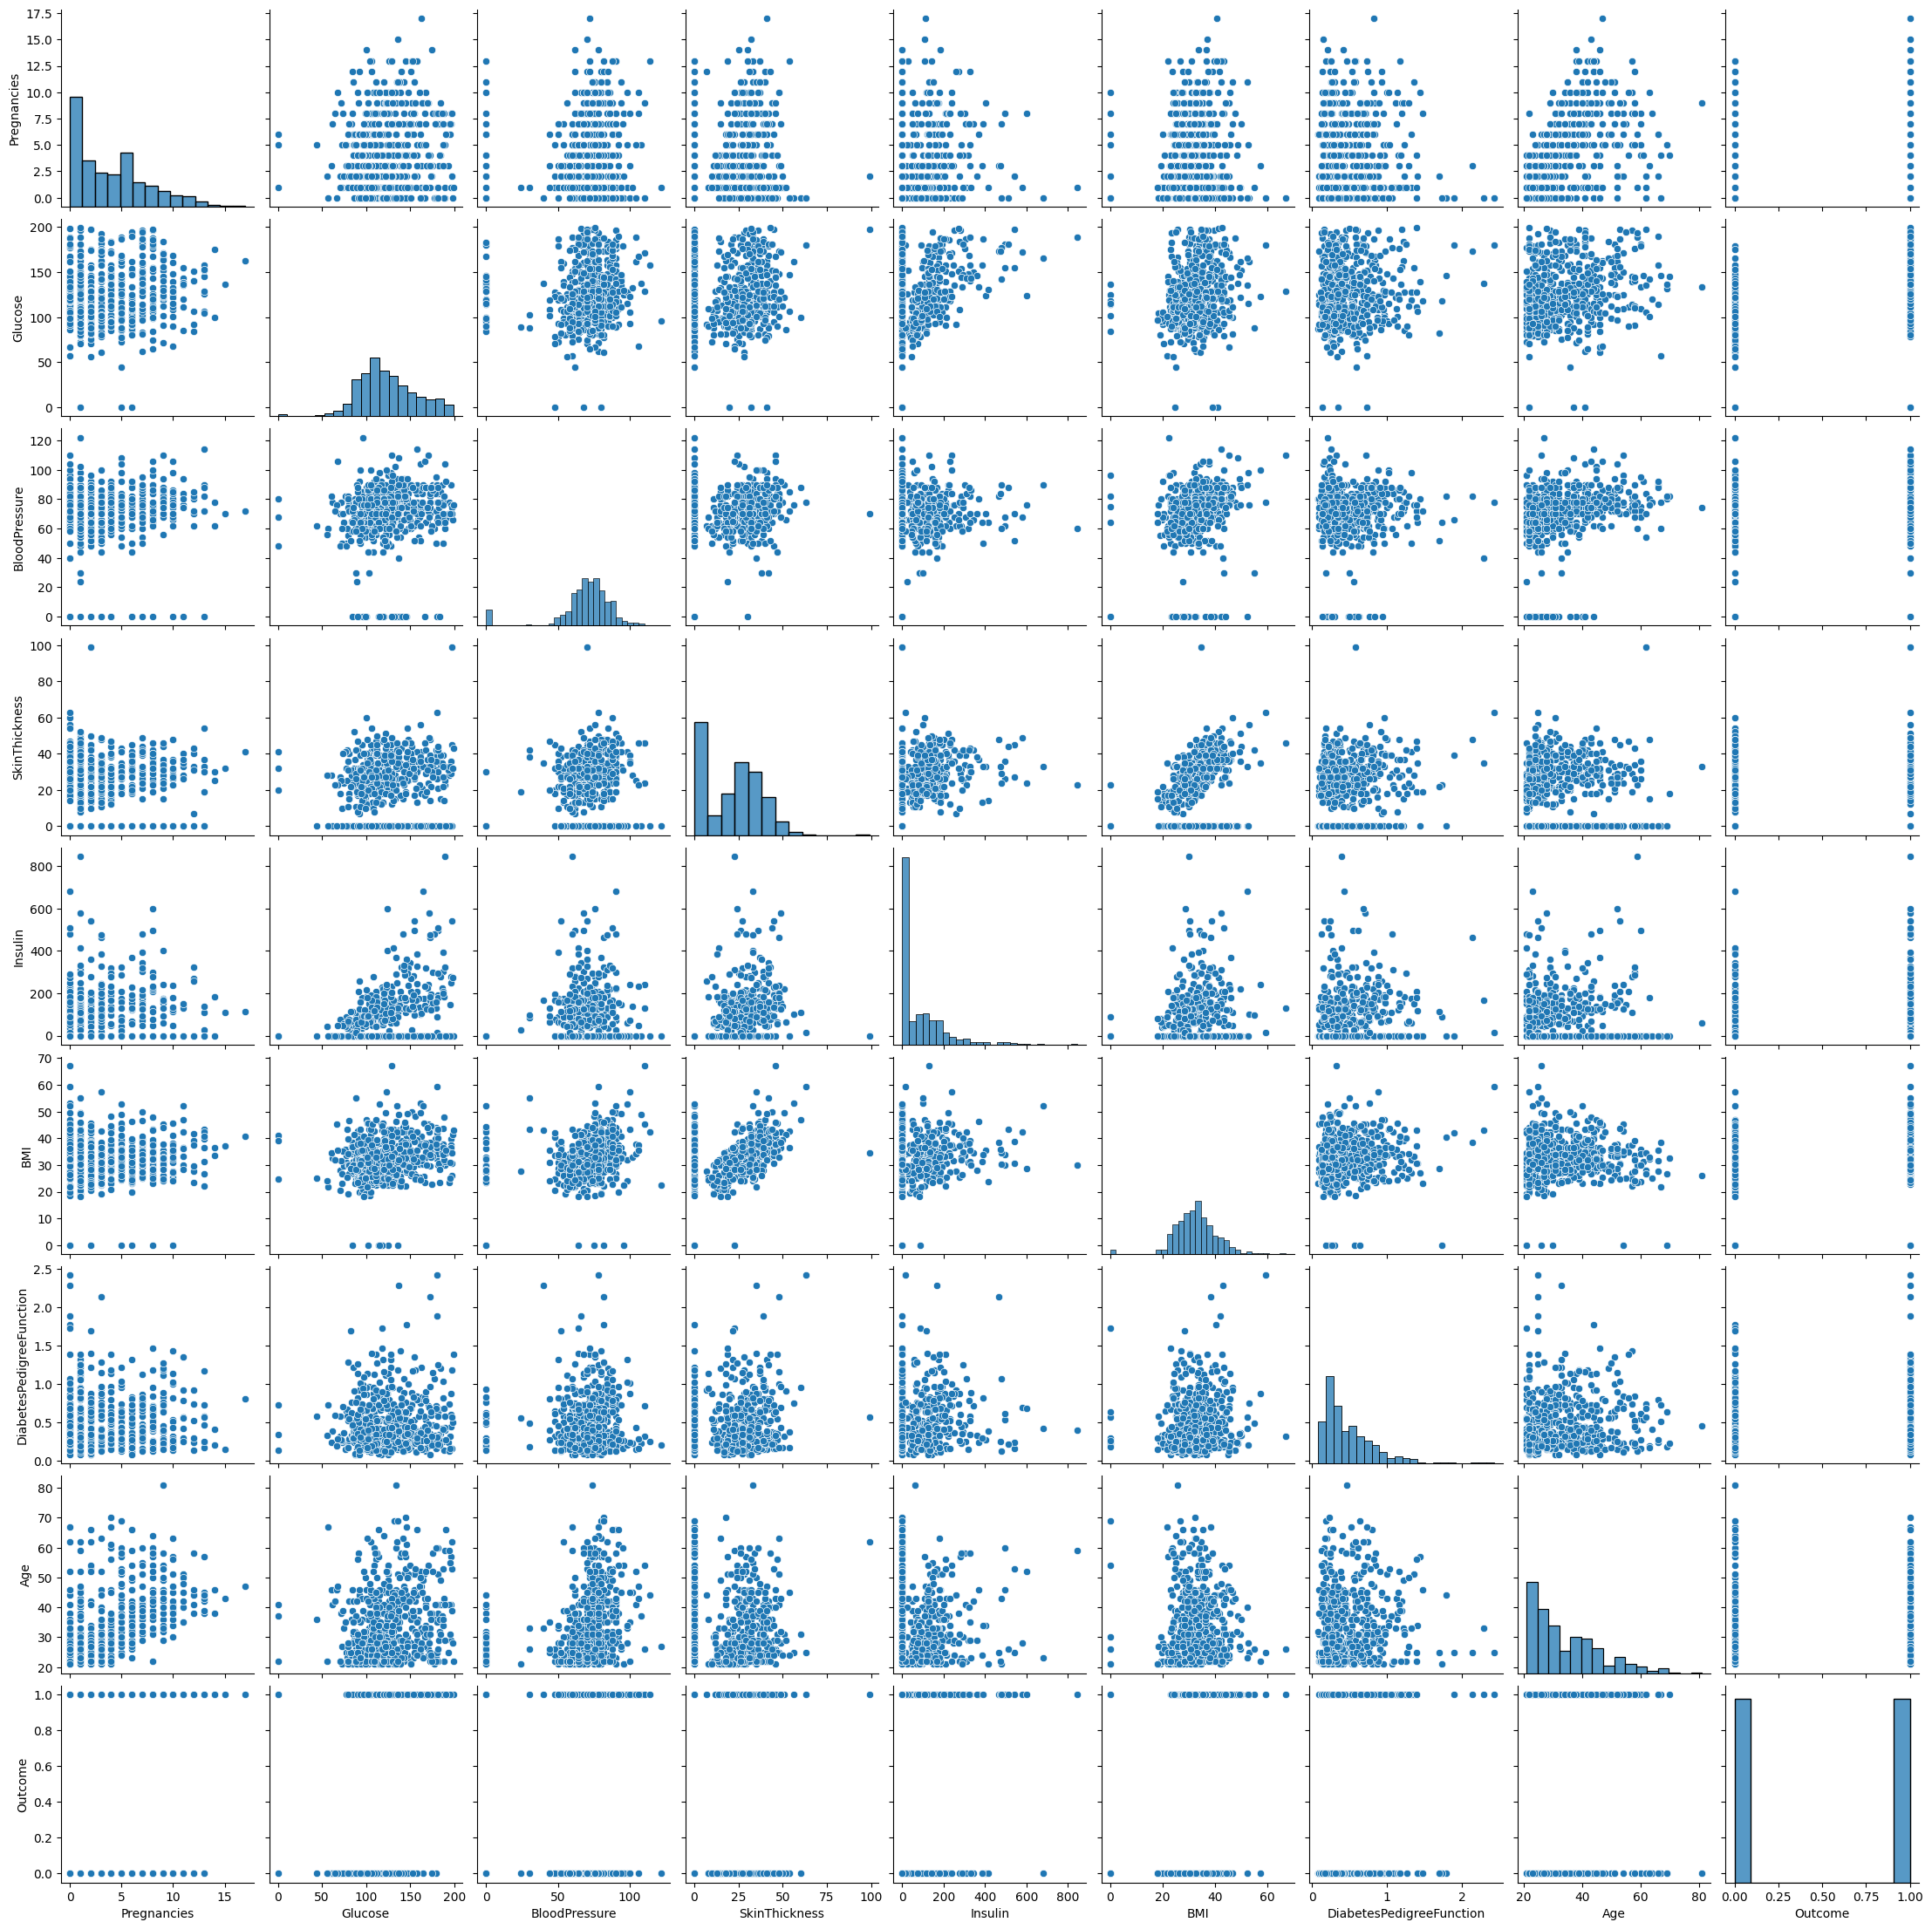

In [80]:
plt.figure(figsize=(8,6))
sns.pairplot(df)
plt.show()

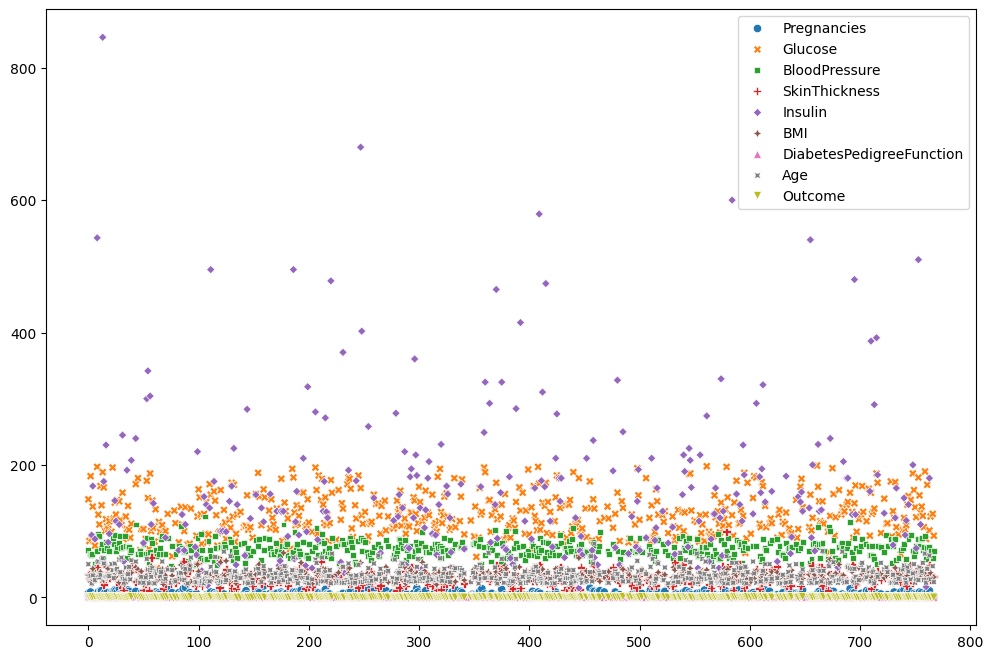

In [81]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df)
plt.show()

In [82]:
df.corrwith(df["Outcome"]).sort_values()

,0
BloodPressure,0.051088
SkinThickness,0.078671
Insulin,0.149357
DiabetesPedigreeFunction,0.161606
Pregnancies,0.222775
Age,0.264165
BMI,0.314225
Glucose,0.509539
Outcome,1.000000


In [83]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
761,9,170,74,31,0,44.0,0.403,43,1
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
766,1,126,60,0,0,30.1,0.349,47,1


In [84]:
y = df['Outcome']
X = df.drop('Outcome', axis=1)


In [85]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, train_size=0.8)


In [86]:
y_train

,Outcome
493,1
630,1
597,0
200,0
263,0
...,...
93,1
141,0
377,0
620,0


In [87]:
ss = StandardScaler()
X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.fit_transform(X_test)




In [88]:
# build model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_ss,y_train)


KNeighborsClassifier()

In [89]:
knn_p = knn.predict(X_test_ss)
print(classification_report(knn_p, y_test))

              precision    recall  f1-score   support

           0       0.92      0.70      0.79        69
           1       0.62      0.90      0.74        39

    accuracy                           0.77       108
   macro avg       0.77      0.80      0.77       108
weighted avg       0.82      0.77      0.77       108



--------------------------------
Eng yaxshi n_neighbors bu 8 ekan. 
--------------------------------


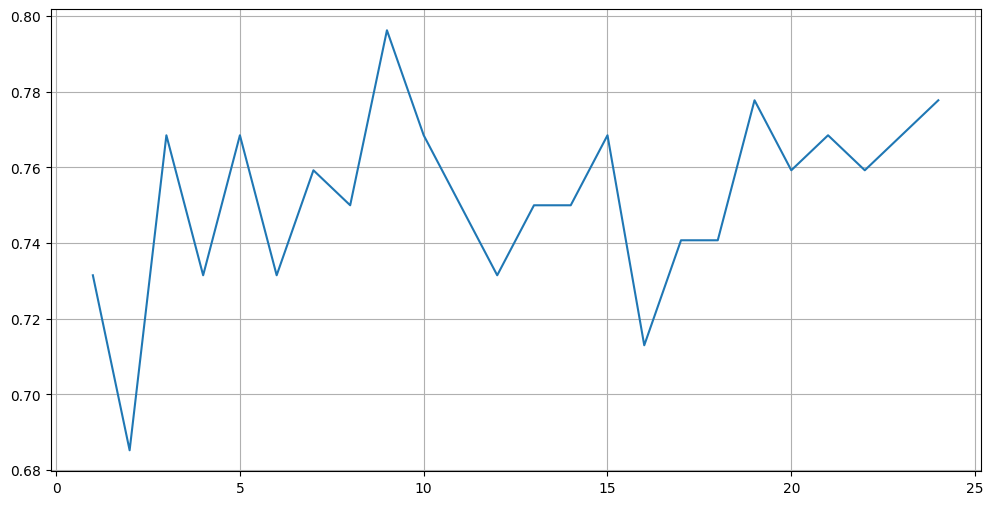

In [92]:
f = []
for i in range(1,25):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train_ss,y_train)
  knn.predict(X_test_ss)
  f.append(accuracy_score(knn.predict(X_test_ss), y_test))
print("-"*32)
print(f"Eng yaxshi n_neighbors bu {f.index(max(f))} ekan. ")
print("-"*32)

plt.figure(figsize=(12,6))
plt.plot(range(1,25), f)
plt.grid()
plt.show()

In [97]:
# taqsimotdan oldingi data bilan ham ishlab ko'ramiz.
df_0['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [99]:
y = df_0['Outcome']
X = df_0.drop('Outcome', axis=1)

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, train_size=0.8)
ss = StandardScaler()
X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.fit_transform(X_test)
# build model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_ss,y_train)





KNeighborsClassifier()

In [101]:
knn_p = knn.predict(X_test_ss)
print(classification_report(knn_p, y_test))

              precision    recall  f1-score   support

           0       0.84      0.73      0.78       114
           1       0.44      0.60      0.51        40

    accuracy                           0.69       154
   macro avg       0.64      0.66      0.64       154
weighted avg       0.73      0.69      0.71       154



--------------------------------
Eng yaxshi n_neighbors bu 22 ekan. 
--------------------------------


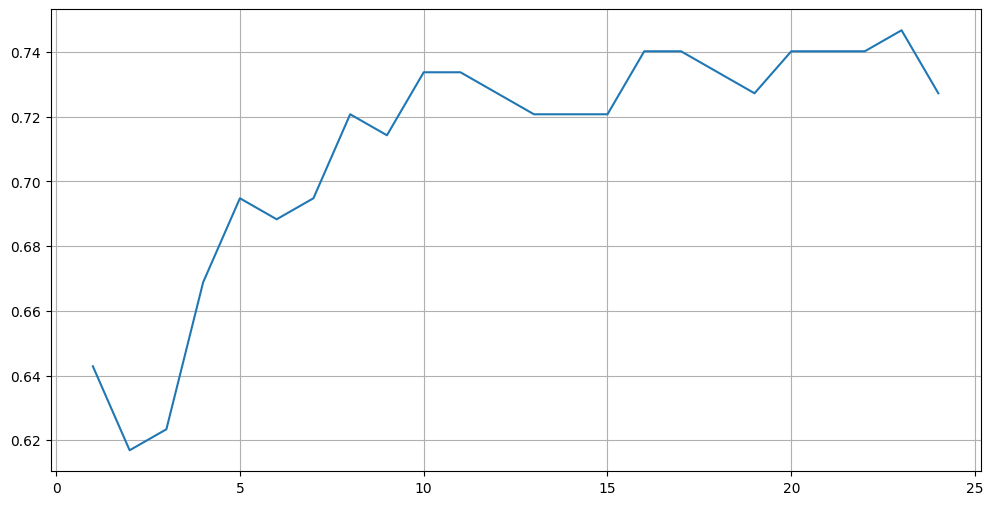

In [102]:
f = []
for i in range(1,25):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train_ss,y_train)
  knn.predict(X_test_ss)
  f.append(accuracy_score(knn.predict(X_test_ss), y_test))
print("-"*32)
print(f"Eng yaxshi n_neighbors bu {f.index(max(f))} ekan. ")
print("-"*32)

plt.figure(figsize=(12,6))
plt.plot(range(1,25), f)
plt.grid()
plt.show()